# Model Development

* Proposed model is based on a 3D U-Net architecture for volumetric cardiac MRI segmentation.
* Incorporates Deformable Convolution Blocks to adapt receptive fields for irregular cardiac boundaries.
Deformable convolutions improve delineation of the myocardium and ventricle walls.
* Integrates Convolutional Block Attention Module (CBAM) for channel and spatial attention refinement.
Channel attention identifies informative feature maps using global pooling and lightweight MLP layers.
* Spatial attention highlights clinically relevant cardiac regions using pooled descriptors and a 7×7 convolution.
Architecture contains 4 encoder stages, bottleneck, and 4 decoder stages.
* Encoder 1 & 2 use standard convolutions with Leaky ReLU for low-level feature extraction.
* Encoder 3 & 4 use deformable convolutions for adaptive boundary learning.
Bottleneck includes deformable convolution layers for enhanced receptive-field learning.
Decoder blocks use skip connections for multi-scale feature fusion.
* CBAM is applied after the bottleneck to improve segmentation of:
Right Ventricle (RV)
Myocardium
Left Ventricle (LV)
* Attention-guided skip connections suppress irrelevant background features and enhance salient cardiac regions.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K

# -----------------------
# Hyperparams / defaults
# -----------------------
L2_REG = 1e-4
DROPOUT = 0.3

# -----------------------
# Utility: GroupNorm3D
# -----------------------
class GroupNorm3D(layers.Layer):
    def __init__(self, groups=8, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.groups = groups
        self.epsilon = epsilon

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.groups_adapted = self.groups if (C % self.groups == 0) else 1
        self.gamma = self.add_weight(name='gamma', shape=(C,), initializer='ones', trainable=True)
        self.beta = self.add_weight(name='beta', shape=(C,), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        B, H, W, D, C = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3], tf.shape(x)[4]
        G = self.groups_adapted

        x_reshaped = tf.reshape(x, [B, H, W, D, G, C // G])
        mean, var = tf.nn.moments(x_reshaped, axes=[1, 2, 3, 5], keepdims=True)
        x_norm = (x_reshaped - mean) / tf.sqrt(var + self.epsilon)
        x_norm = tf.reshape(x_norm, [B, H, W, D, C])
        return x_norm * self.gamma + self.beta

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"groups": self.groups, "epsilon": self.epsilon})
        return cfg


# -----------------------
# Trilinear sampler (vectorized)
# vol: [B, H, W, D, C]
# coords: [B, H, W, D, K, 3] # absolute voxel coords (z, y, x) ordering consistent with our grid
# returns: [B, H, W, D, K, C]
# -----------------------
def trilinear_sampler(vol, coords):
    """
    vol:    [B, H, W, D, C]
    coords: [B, H, W, D, K, 3]  # absolute voxel coords (z,y,x)
    return: [B, H, W, D, K, C]
    """
    vol = tf.convert_to_tensor(vol)
    coords = tf.convert_to_tensor(coords)

    B = tf.shape(vol)[0]
    H = tf.shape(vol)[1]
    W = tf.shape(vol)[2]
    D = tf.shape(vol)[3]
    C = tf.shape(vol)[4]

    z = coords[..., 0]
    y = coords[..., 1]
    x = coords[..., 2]

    # floor / ceil
    z0 = tf.floor(z)
    z1 = z0 + 1.0
    y0 = tf.floor(y)
    y1 = y0 + 1.0
    x0 = tf.floor(x)
    x1 = x0 + 1.0

    # clip to valid range
    z0 = tf.clip_by_value(z0, 0.0, tf.cast(H - 1, tf.float32))
    z1 = tf.clip_by_value(z1, 0.0, tf.cast(H - 1, tf.float32))
    y0 = tf.clip_by_value(y0, 0.0, tf.cast(W - 1, tf.float32))
    y1 = tf.clip_by_value(y1, 0.0, tf.cast(W - 1, tf.float32))
    x0 = tf.clip_by_value(x0, 0.0, tf.cast(D - 1, tf.float32))
    x1 = tf.clip_by_value(x1, 0.0, tf.cast(D - 1, tf.float32))

    # int indices
    z0_i = tf.cast(z0, tf.int32)
    z1_i = tf.cast(z1, tf.int32)
    y0_i = tf.cast(y0, tf.int32)
    y1_i = tf.cast(y1, tf.int32)
    x0_i = tf.cast(x0, tf.int32)
    x1_i = tf.cast(x1, tf.int32)

    # interpolation weights
    wz1 = z - z0
    wz0 = 1.0 - wz1
    wy1 = y - y0
    wy0 = 1.0 - wy1
    wx1 = x - x0
    wx0 = 1.0 - wx1

    def gather(b, z, y, x):
        """
        b,z,y,x are [B,H,W,D,K]
        returns gathered values [B,H,W,D,K,C]
        """
        idx = tf.stack([b, z, y, x], axis=-1)  # [...,4]
        gathered = tf.gather_nd(vol, idx)
        return gathered

    # batch index
    b_idx = tf.reshape(tf.range(B, dtype=tf.int32), [B,1,1,1,1])
    b_idx = tf.tile(b_idx, [1, H, W, D, tf.shape(coords)[4]])

    # gather 8 neighbors
    c000 = gather(b_idx, z0_i, y0_i, x0_i)
    c001 = gather(b_idx, z0_i, y0_i, x1_i)
    c010 = gather(b_idx, z0_i, y1_i, x0_i)
    c011 = gather(b_idx, z0_i, y1_i, x1_i)
    c100 = gather(b_idx, z1_i, y0_i, x0_i)
    c101 = gather(b_idx, z1_i, y0_i, x1_i)
    c110 = gather(b_idx, z1_i, y1_i, x0_i)
    c111 = gather(b_idx, z1_i, y1_i, x1_i)

    # apply weights
    out = (
        c000 * (wz0*wy0*wx0)[...,None] +
        c001 * (wz0*wy0*wx1)[...,None] +
        c010 * (wz0*wy1*wx0)[...,None] +
        c011 * (wz0*wy1*wx1)[...,None] +
        c100 * (wz1*wy0*wx0)[...,None] +
        c101 * (wz1*wy0*wx1)[...,None] +
        c110 * (wz1*wy1*wx0)[...,None] +
        c111 * (wz1*wy1*wx1)[...,None]
    )
    return out  # [B,H,W,D,K,C]


# -----------------------
# DeformableConv3D layer
# -----------------------
class DeformableConv3D(layers.Layer):
    def __init__(self, filters, kernel_size=3, padding='same', use_bias=False, kernel_regularizer=None, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = int(kernel_size)
        self.padding = padding
        self.use_bias = use_bias
        self.kernel_regularizer = kernel_regularizer

    def build(self, input_shape):
        C = int(input_shape[-1])
        k = self.kernel_size
        # conv kernel
        self.kernel = self.add_weight(
            name='kernel',
            shape=(k, k, k, C, self.filters),
            initializer='glorot_uniform',
            regularizer=self.kernel_regularizer,
            trainable=True
        )
        if self.use_bias:
            self.bias = self.add_weight(name='bias', shape=(self.filters,), initializer='zeros', trainable=True)
        else:
            self.bias = None

        # offset conv: produces (3 * k^3) channels
        self.offset_conv = layers.Conv3D(
            filters=3 * (k ** 3),
            kernel_size=k,
            padding=self.padding,
            kernel_initializer='zeros',
            bias_initializer='zeros',
            name='offset_conv'
        )
        super().build(input_shape)

    def call(self, x):
        """
        x: [B, H, W, D, C]    (note: we'll treat axis order as H,W,D)
        TensorFlow conv3d convention is [batch, depth, height, width, channels] often;
        This implementation expects [B, H, W, D, C] as used earlier — keep consistent.
        We'll assume input shape is [B, H, W, D, C] as in your code.
        """
        # Predict offsets
        offsets = self.offset_conv(x)  # [B, H, W, D, 3*k^3]
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        D = tf.shape(x)[3]
        C = tf.shape(x)[4]
        k = self.kernel_size
        k3 = k ** 3

        # reshape offsets -> [B, H, W, D, k^3, 3]
        offsets = tf.reshape(offsets, [B, H, W, D, k3, 3])

        # build kernel grid in (z,y,x) where z->H axis, y->W, x->D for consistent indexing
        # center offsets: ranges [-(k//2) ... k//2]
        rng = tf.range(-(k // 2), k // 2 + 1, dtype=tf.float32)
        dz, dy, dx = tf.meshgrid(rng, rng, rng, indexing='ij')  # each shape [k,k,k]
        kernel_grid = tf.stack([dz, dy, dx], axis=-1)  # [k,k,k,3]
        kernel_grid = tf.reshape(kernel_grid, (1, 1, 1, 1, k3, 3))  # broadcastable

        # sampling locations = base grid (voxel coords) + kernel grid + predicted offsets
        # base grid: coordinates for each voxel (z,y,x) where z in [0..H-1], y [0..W-1], x [0..D-1]
        zz, yy, xx = tf.meshgrid(tf.range(H, dtype=tf.float32),
                                 tf.range(W, dtype=tf.float32),
                                 tf.range(D, dtype=tf.float32),
                                 indexing='ij')  # shapes [H,W,D]
        base_grid = tf.stack([zz, yy, xx], axis=-1)  # [H,W,D,3]
        base_grid = tf.reshape(base_grid, (1, H, W, D, 1, 3))  # [1,H,W,D,1,3]

        sampling_locations = base_grid + kernel_grid + offsets  # [B,H,W,D,k3,3]

        # sample features
        sampled = trilinear_sampler(x, sampling_locations)  # [B,H,W,D,k3,C]

        # now apply kernel weights:
        # kernel shape: [k,k,k,C,filters] -> reshape to [k3, C, filters]
        kernel_flat = tf.reshape(self.kernel, (k3, tf.shape(self.kernel)[3], tf.shape(self.kernel)[4]))  # [k3, C, filters]

        # tensordot sampled [B,H,W,D,k3,C] with kernel_flat [k3,C,filters] -> contract k3 and C -> output [B,H,W,D,filters]
        out = tf.tensordot(sampled, kernel_flat, axes=[[4,5],[0,1]])  # -> [B,H,W,D,filters]

        if self.bias is not None:
            out = out + self.bias

        return out

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.filters,)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"filters": self.filters, "kernel_size": self.kernel_size, "padding": self.padding, "use_bias": self.use_bias})
        return cfg

# -----------------------
# Custom Keras Layers for TensorFlow operations
# -----------------------
class ChannelAttention3D(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channel = input_shape[-1]
        self.shared_dense = models.Sequential([
            layers.Dense(self.channel // self.reduction_ratio, activation='relu'),
            layers.Dense(self.channel)
        ])
        super().build(input_shape)

    def call(self, x):
        avg_pool = K.mean(x, axis=[1, 2, 3], keepdims=True)
        max_pool = K.max(x, axis=[1, 2, 3], keepdims=True)

        avg_out = self.shared_dense(avg_pool)
        max_out = self.shared_dense(max_pool)

        channel_attention = tf.nn.sigmoid(avg_out + max_out)
        return x * channel_attention

class SpatialAttention3D(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.spatial_conv = layers.Conv3D(1, 7, padding='same', activation='sigmoid')

    def call(self, x):
        avg_pool = K.mean(x, axis=-1, keepdims=True)
        max_pool = K.max(x, axis=-1, keepdims=True)
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        spatial_attention = self.spatial_conv(concat)
        return x * spatial_attention

class CBAM3D(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.channel_attention = ChannelAttention3D(reduction_ratio)
        self.spatial_attention = SpatialAttention3D()

    def call(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

# -----------------------
# Residual blocks
# -----------------------
def res_conv3d_block(x, filters, name, groups=8, dropout_rate=DROPOUT, l2_reg=None):
    shortcut = layers.Conv3D(filters, 1, padding='same',
                             kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None,
                             name=f"{name}_shortcut")(x)

    y = layers.Conv3D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None,
                      name=f"{name}_conv1")(x)
    y = GroupNorm3D(groups=groups, name=f"{name}_gn1")(y)
    y = layers.LeakyReLU(negative_slope=0.01)(y)
    y = layers.SpatialDropout3D(dropout_rate)(y)

    y = layers.Conv3D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None ,
                      name=f"{name}_conv2")(y)
    y = GroupNorm3D(groups=groups, name=f"{name}_gn2")(y)

    out = layers.Add(name=f"{name}_add")([shortcut, y])
    out = layers.LeakyReLU(negative_slope=0.01)(out)
    return out

def res_deform_block_3d(x, filters, name, groups=8, dropout_rate=DROPOUT, l2_reg=None):
    shortcut = layers.Conv3D(filters, 1, padding='same',
                             kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None ,
                             name=f"{name}_shortcut")(x)

    y = DeformableConv3D(filters, kernel_size=3, name=f"{name}_deform1")(x)
    y = GroupNorm3D(groups=groups, name=f"{name}_dgn1")(y)
    y = layers.LeakyReLU(negative_slope=0.01)(y)
    y = layers.SpatialDropout3D(dropout_rate)(y)

    y = DeformableConv3D(filters, kernel_size=3, name=f"{name}_deform2")(y)
    y = GroupNorm3D(groups=groups, name=f"{name}_dgn2")(y)

    out = layers.Add(name=f"{name}_dadd")([shortcut, y])
    out = layers.LeakyReLU(negative_slope=0.01)(out)
    return out

# -----------------------
# Attention Gate
# -----------------------
def attention_gate_3d(skip, gating, inter_channels, name=None, l2_reg=L2_REG):
    # 1x1x1 conv to reduce channels
    theta_x = layers.Conv3D(inter_channels, 1, padding='same',
                            kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None ,
                            name=f"{name}_theta" if name else None)(skip)
    phi_g = layers.Conv3D(inter_channels, 1, padding='same',
                          kernel_regularizer=regularizers.l2(l2_reg) if l2_reg else None,
                          name=f"{name}_phi" if name else None)(gating)

    # Add and activate
    add = layers.Add()([theta_x, phi_g])
    act = layers.LeakyReLU(negative_slope=0.01)(add)

    # Attention coefficients
    psi = layers.Conv3D(1, 1, padding='same', activation='sigmoid',
                        kernel_regularizer=regularizers.l2(l2_reg)  if l2_reg else None ,
                        name=f"{name}_psi" if name else None)(act)

    # Apply attention
    out = layers.Multiply()([skip, psi])
    return out

# -----------------------
# Full model builder
# -----------------------
def unet3d_res_deform_cbam_acdc(input_shape=(224, 224, 8, 1), num_classes=4, base_filters=32, groups=16):
    inputs = layers.Input(shape=input_shape)

    # Encoder path - Only pool in spatial dimensions (H, W), keep depth (D) unchanged
    enc1 = res_conv3d_block(inputs, base_filters, name="enc1", groups=groups, l2_reg=None, dropout_rate=0.1)
    p1 = layers.MaxPooling3D(pool_size=(2, 2, 1), name="p1")(enc1)  # H/2, W/2, D unchanged

    enc2 = res_conv3d_block(p1, base_filters*2, name="enc2", groups=groups, l2_reg=None, dropout_rate=0.1)
    p2 = layers.MaxPooling3D(pool_size=(2, 2, 1), name="p2")(enc2)  # H/4, W/4, D unchanged

    enc3 = res_deform_block_3d(p2, base_filters*4, name="enc3", groups=groups, l2_reg=None, dropout_rate=0.2)
    p3 = layers.MaxPooling3D(pool_size=(2, 2, 1), name="p3")(enc3)  # H/8, W/8, D unchanged

    enc4 = res_deform_block_3d(p3, base_filters*8, name="enc4", groups=groups, l2_reg=L2_REG, dropout_rate=0.3)
    p4 = layers.MaxPooling3D(pool_size=(2, 2, 1), name="p4")(enc4)  # H/16, W/16, D unchanged

    # Bottleneck with CBAM - FIXED: added bottleneck1
    bottleneck = res_deform_block_3d(p4, base_filters*16, name="bottleneck1", groups=groups,l2_reg=L2_REG, dropout_rate=0.4)
    bottleneck = res_deform_block_3d(bottleneck, base_filters*16, name="bottleneck2", groups=groups)
    bottleneck = CBAM3D(reduction_ratio=8, name="cbam_bottleneck")(bottleneck)
    bottleneck = layers.SpatialDropout3D(0.5, name="bottleneck_dropout")(bottleneck)

    # Decoder path
    up4 = layers.Conv3DTranspose(base_filters*8, kernel_size=(2, 2, 1), strides=(2, 2, 1),
                                 padding="same", name="up4")(bottleneck)
    skip4 = attention_gate_3d(enc4, up4, inter_channels=base_filters*4, name="att4", l2_reg=L2_REG)
    up4 = layers.Concatenate(name="concat4")([up4, skip4])
    dec4 = res_conv3d_block(up4, base_filters*8, name="dec4", groups=groups, l2_reg=L2_REG, dropout_rate=0.3)

    up3 = layers.Conv3DTranspose(base_filters*4, kernel_size=(2, 2, 1), strides=(2, 2, 1),
                                 padding="same", name="up3")(dec4)
    skip3 = attention_gate_3d(enc3, up3, inter_channels=base_filters*2, name="att3", l2_reg=L2_REG)
    up3 = layers.Concatenate(name="concat3")([up3, skip3])
    dec3 = res_conv3d_block(up3, base_filters*4, name="dec3", groups=groups, l2_reg=L2_REG, dropout_rate=0.2)

    up2 = layers.Conv3DTranspose(base_filters*2, kernel_size=(2, 2, 1), strides=(2, 2, 1),
                                 padding="same", name="up2")(dec3)
    skip2 = attention_gate_3d(enc2, up2, inter_channels=base_filters, name="att2", l2_reg=None)
    up2 = layers.Concatenate(name="concat2")([up2, skip2])
    dec2 = res_conv3d_block(up2, base_filters*2, name="dec2", groups=groups, l2_reg=None, dropout_rate=0.1)

    up1 = layers.Conv3DTranspose(base_filters, kernel_size=(2, 2, 1), strides=(2, 2, 1),
                                 padding="same", name="up1")(dec2)
    skip1 = attention_gate_3d(enc1, up1, inter_channels=max(base_filters//2, 1), name="att1", l2_reg=None)  # FIXED: ensure at least 1 channel
    up1 = layers.Concatenate(name="concat1")([up1, skip1])
    dec1 = res_conv3d_block(up1, base_filters, name="dec1", groups=groups, l2_reg=None, dropout_rate=0.1)

    # Output layer
    logits = layers.Conv3D(num_classes, kernel_size=1, padding='same',
                           kernel_regularizer=regularizers.l2(L2_REG),
                           name="logits")(dec1)
    outputs = layers.Activation('softmax', dtype='float32', name='softmax')(logits)

    return models.Model(inputs=inputs, outputs=outputs, name="UNet3D_ResDeform_CBAM_ACDC")
# Create and verify the model
# model = unet3d_res_deform_cbam_acdc(input_shape=(128, 128, 8, 1), num_classes=4, base_filters=32, groups=8)
# model.summary()



**Model Training Strategy**
* Model trained using a hybrid loss function combining:
50% Dice Loss
50% Sparse Categorical Cross-Entropy Loss
* Hybrid loss improves segmentation stability and accuracy by balancing overlap precision and pixel-wise classification.
Optimization performed using the Adam optimizer with an initial learning rate of 0.0005.
* Adaptive learning rate scheduling progressively reduces the learning rate up to 1e-10 when validation Dice score stagnates for 3 epochs.
Early stopping with patience of 70 epochs prevents overfitting and unnecessary computation.
* Model checkpointing retains the best-performing model based on validation Dice coefficient.
* Gradient accumulation (16 steps) simulates a larger batch size while training with batch size = 1.
* Integrated Group Normalization (16 groups) for stable feature statistics and improved generalization in small-batch training scenarios.

In [ ]:
import tensorflow as tf

NUM_CLASSES = 4  # Background, RV, MYO, LV
# Background=0, RV=1, MYO=2, LV=3
CLASS_WEIGHTS = tf.constant([0.05,5.0,10.0, 1.0], dtype=tf.float32)

def weighted_ce_dice_loss(y_true, y_pred):
    smooth = tf.keras.backend.epsilon()

    # One-hot encode labels
    y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
    y_pred = tf.cast(y_pred, tf.float32)

    # -------------------------
    # Weighted Cross Entropy (probabilities expected here)
    # -------------------------
    ce = -tf.reduce_sum(
        y_true_onehot * tf.math.log(tf.clip_by_value(y_pred, smooth, 1.0)) * CLASS_WEIGHTS,
        axis=-1
    )
    ce_loss = tf.reduce_mean(ce)

    # -------------------------
    # Weighted Dice Loss
    # -------------------------
    y_true_f = tf.reshape(y_true_onehot, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    denom = tf.reduce_sum(y_true_f + y_pred_f, axis=1)

    dice_per_class = (2. * intersection + smooth) / (denom + smooth)

    class_weights_norm = CLASS_WEIGHTS / tf.reduce_sum(CLASS_WEIGHTS)
    dice_loss = 1.0 - tf.reduce_sum(class_weights_norm * dice_per_class, axis=-1)

    # Final loss
    return ce_loss + tf.reduce_mean(dice_loss)


# ----------------------------
# Dice Metrics
# ----------------------------
def dice_coefficient(y_true, y_pred):
    smooth = tf.keras.backend.epsilon()
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)  # (B,H,W,D,C)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    denom = tf.reduce_sum(y_true_f + y_pred_f, axis=1)

    dice = (2. * intersection + smooth) / (denom + smooth)
    return tf.reduce_mean(dice)

def dice_coefficient_class(c, name):
    def dice(y_true, y_pred):
        smooth = tf.keras.backend.epsilon()
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        y_true_c = tf.cast(y_true[..., c], tf.float32)
        y_pred_c = tf.cast(y_pred[..., c], tf.float32)

        y_true_f = tf.reshape(y_true_c, [tf.shape(y_true_c)[0], -1])
        y_pred_f = tf.reshape(y_pred_c, [tf.shape(y_pred_c)[0], -1])

        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
        denom = tf.reduce_sum(y_true_f + y_pred_f, axis=1)

        dice = (2. * intersection + smooth) / (denom + smooth)
        return tf.reduce_mean(dice)
    dice.__name__ = name
    return dice



In [ ]:
base_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5,
    gradient_accumulation_steps=32   # ✅ built-in accumulation
)

model.compile(
    optimizer=optimizer,
    loss=weighted_ce_dice_loss,
    metrics=[
        dice_coefficient,
        dice_coefficient_class(1, "dice_RV"),
        dice_coefficient_class(2, "dice_MYO"),
        dice_coefficient_class(3, "dice_LV"),
    ]
)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        monitor='val_dice_coefficient',
        patience=70,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-10,
        verbose=1
    ),
    ModelCheckpoint(
    filepath="/content/drive/MyDrive/Folder/ACDC/database/06oct(new)/best_model.weights.h5",  # better naming for clarity
    monitor="val_dice_coefficient",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)
]

In [ ]:
#03/10
model = unet3d_res_deform_cbam_acdc(input_shape=(128,128,8,1), num_classes=4, base_filters=32, groups=8)


# 2. Build by running a dummy input through it
dummy_input = tf.zeros((1,128,128,8,1))
_ = model(dummy_input)   # forces build

model.load_weights(r"/content/drive/MyDrive/Folder/ACDC/database/04oct(new)/best_model.weights.h5")


optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-4,
    gradient_accumulation_steps=8   # ✅ built-in accumulation
)


model.compile(
    optimizer=optimizer,
    loss=weighted_ce_dice_loss,
    metrics=[
        dice_coefficient,
        dice_coefficient_class(1, "dice_RV"),
        dice_coefficient_class(2, "dice_MYO"),
        dice_coefficient_class(3, "dice_LV"),
    ]
)


In [ ]:
#06/10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=500,
    callbacks=[callbacks],
    shuffle=True,
    verbose=1
)

Epoch 1/500
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - dice_coefficient: 0.9062 - dice_lv: 0.9196 - dice_myo: 0.8466 - dice_rv: 0.8613 - loss: 0.1940
Epoch 1: val_dice_coefficient improved from -inf to 0.88740, saving model to /content/drive/MyDrive/Folder/ACDC/database/06oct(new)/best_model.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 404s 386ms/step - dice_coefficient: 0.9062 - dice_lv: 0.9196 - dice_myo: 0.8466 - dice_rv: 0.8613 - loss: 0.1940 - val_dice_coefficient: 0.8874 - val_dice_lv: 0.9137 - val_dice_myo: 0.8281 - val_dice_rv: 0.8107 - val_loss: 0.2263 - learning_rate: 5.0000e-04
Epoch 2/500
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - dice_coefficient: 0.9045 - dice_lv: 0.9145 - dice_myo: 0.8438 - dice_rv: 0.8623 - loss: 0.1983
Epoch 2: val_dice_coefficient improved from 0.88740 to 0.89334, saving model to /content/drive/MyDrive/Folder/ACDC/database/06oct(new)/best_model.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 307s 384ms/step - dice_coefficient: 0.9045 - dice_lv: 0.9145 - dice_m

**Patient's Cardiac Profile Extraction**

* Predicted segmentation masks were used to automatically extract patient-specific cardiac biomarkers.
Extracted biomarkers include:
End Diastolic Volume (EDV)
End Systolic Volume (ESV)
Stroke Volume (SV)
Ejection Fraction (EF)
Myocardial Wall Thickness
Septal Thickness
* Biomarkers capture both functional and structural cardiac properties.
Extracted features were aggregated into a structured tabular dataset for disease prediction.
* Developed a hybrid TabNet–Transformer classification model for cardiac disease classification.
* TabNet enables attentive feature selection and improves interpretability by focusing on influential biomarkers.
* Transformer encoder captures long-range dependencies and relationships between volumetric and morphological features using self-attention.
Hybrid architecture combines:
Interpretability
Feature reasoning
High representational capability
* Model is designed to classify overlapping cardiac pathologies such as:
Right Ventricular Abnormality (RVA)
Myocardial Infarction (MINF)
Dilated Cardiomyopathy (DCM)
Hypertrophic Cardiomyopathy (HCM)

In [ ]:
# Full pipeline: predict masks per patient, extract features, save CSV
# Colab-ready. Edit paths & model call as necessary.

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from skimage.transform import resize
from skimage.draw import line
from scipy.ndimage import distance_transform_edt, center_of_mass
from scipy.spatial import cKDTree
import tensorflow as tf
from tqdm import tqdm

# -----------------------
# USER CONFIG - EDIT
# -----------------------
data_dir = "/content/drive/MyDrive/cardiac/ACDC/database/training"   # patient folders
out_csv = "/content/drive/MyDrive/SegmentationResults/train_patient_features_from_predicted_masks.csv"
target_shape = (128, 128)   # in-plane resize (H, W)
depth = 8                   # slices to center-crop/pad
n_angles = 180              # radial sampling resolution
fallback_spacing = (1.25, 1.25, 10.0)   # mm (row, col, slice) if header missing
model_weights_path ="/content/drive/MyDrive/Folder/ACDC/database/06oct(new)/06octbest_model.weights.h5"

# -----------------------
# Helper utilities
# -----------------------
def fix_depth(volume, target_depth):
    """Center crop or pad along depth axis to match target_depth."""
    current_depth = volume.shape[-1]
    if current_depth > target_depth:
        start = (current_depth - target_depth) // 2
        return volume[..., start:start+target_depth]
    elif current_depth < target_depth:
        pad_before = (target_depth - current_depth) // 2
        pad_after = target_depth - current_depth - pad_before
        return np.pad(volume, ((0,0),(0,0),(pad_before,pad_after)), mode='constant', constant_values=0)
    return volume

def find_ed_es_files(patient_folder):
    """Return (ed_file, es_file) paths for image volumes (ignore _gt files)."""
    files = [f for f in os.listdir(patient_folder) if (f.endswith(".nii") or f.endswith(".nii.gz"))]
    # prefer explicit 'frame01' naming for ED, exclude any _gt
    ed_candidates = [f for f in files if "frame01" in f and "_gt" not in f]
    es_candidates = [f for f in files if "frame" in f and "frame01" not in f and "_gt" not in f]
    # fallback: if ED not found, pick any non-gt file
    if not ed_candidates:
        ed_candidates = [f for f in files if "_gt" not in f]
    if not es_candidates:
        es_candidates = [f for f in files if "_gt" not in f and f not in ed_candidates]
    if not ed_candidates or not es_candidates:
        return None, None
    ed_file = os.path.join(patient_folder, ed_candidates[0])
    es_file = os.path.join(patient_folder, es_candidates[0])
    return ed_file, es_file

def load_image_nii(file_path, target_shape=(224,224), depth=8):
    """Load NIfTI volume, resize in-plane, fix depth. Returns volume (H,W,D) and spacing (row_mm, col_mm, slice_mm)."""
    nii = nib.load(file_path)
    vol = np.asarray(nii.get_fdata(), dtype=np.float32)
    # ensure shape (H,W,D)
    if vol.ndim == 4:
        # if 4D (H,W,D,T) try collapse last if T==1 else pick first temporal frame
        if vol.shape[-1] == 1:
            vol = vol[...,0]
        else:
            vol = vol[...,0]  # fallback
    # Resize in-plane, keep depth as is then fix depth
    H0, W0, D0 = vol.shape
    # resize expects (H,W,D) target; we want to resize only H,W
    vol_resized = resize(vol, target_shape + (D0,), preserve_range=True, order=1, anti_aliasing=True)
    vol_fixed = fix_depth(vol_resized, depth)
    # spacing from header
    try:
        zooms = nii.header.get_zooms()[:3]
        spacing = (float(zooms[0]), float(zooms[1]), float(zooms[2]))
    except Exception:
        spacing = fallback_spacing
    return vol_fixed.astype(np.float32), spacing

def normalize_volume(vol):
    """Simple min-max normalization per volume (keeps zero background)."""
    v = vol.astype(np.float32)
    v_min, v_max = np.min(v), np.max(v)
    if v_max - v_min < 1e-6:
        return np.zeros_like(v)
    return (v - v_min) / (v_max - v_min)

# -----------------------
# Build & load model
# -----------------------
# NOTE: The function unet3d_res_deform_cbam_acdc must be available in the notebook scope.
# If it's defined in another file, import it accordingly.
try:
    model = unet3d_res_deform_cbam_acdc(input_shape=(target_shape[0], target_shape[1], depth, 1),
                                        num_classes=4,
                                        base_filters=32,
                                        groups=8)
    # force build
    _ = model(tf.zeros((1, target_shape[0], target_shape[1], depth, 1)))
    model.load_weights(model_weights_path)
    print("Loaded model and weights.")
except NameError as e:
    raise RuntimeError("Model builder function `unet3d_res_deform_cbam_acdc` not found. Please define or import it.") from e
except Exception as e:
    raise RuntimeError(f"Error loading model weights: {e}") from e

def segment_volume_with_model(vol):
    """
    vol: (H,W,D) float32
    returns: mask (H,W,D) uint8 (labels 0..3)
    """
    # normalize
    inp = normalize_volume(vol)
    inp = np.expand_dims(inp, axis=-1)  # (H,W,D,1)
    inp = np.expand_dims(inp, axis=0)   # (1,H,W,D,1)
    pred = model.predict(inp, verbose=0)  # (1,H,W,D,num_classes)
    pred = pred[0]  # (H,W,D,num_classes)
    mask = np.argmax(pred, axis=-1).astype(np.uint8)
    return mask

# -----------------------
# Feature extraction utilities
# -----------------------
def voxel_volume_ml(spacing):
    return (spacing[0] * spacing[1] * spacing[2]) / 1000.0  # mm^3 -> mL

def compute_volume_ml(binary_mask, spacing):
    return float(np.sum(binary_mask) * voxel_volume_ml(spacing))

def compute_ef(mask_ed, mask_es, spacing):
    edv = compute_volume_ml(mask_ed, spacing)
    esv = compute_volume_ml(mask_es, spacing)
    if edv <= 0:
        return 0.0, round(edv,2), round(esv,2)
    ef = (edv - esv) / edv * 100.0
    return round(ef, 2), round(edv, 2), round(esv, 2)

def nearest_point_in_mask(yx, mask):
    H, W = mask.shape
    iy, ix = int(round(yx[0])), int(round(yx[1]))
    if 0 <= iy < H and 0 <= ix < W and mask[iy, ix]:
        return (iy, ix)
    pts = np.argwhere(mask)
    if pts.size == 0:
        return None
    tree = cKDTree(pts)
    dist, idx = tree.query([yx])
    return tuple(map(int, pts[int(idx[0])]))

def radial_thickness_for_slice(lv_slice, myo_slice, rv_slice, row_mm, col_mm, n_angles=180):
    H, W = lv_slice.shape
    if lv_slice.sum() == 0 or myo_slice.sum() == 0:
        return 0.0, 0.0, 0
    cy, cx = center_of_mass(lv_slice)
    if np.isnan(cx) or np.isnan(cy):
        return 0.0, 0.0, 0
    origin = nearest_point_in_mask((cy, cx), lv_slice)
    if origin is None:
        return 0.0, 0.0, 0
    cy_i, cx_i = origin
    cyf, cxf = float(cy_i), float(cx_i)
    max_radius = np.hypot(H, W)
    angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
    dist_to_lv = distance_transform_edt(~lv_slice, sampling=(row_mm, col_mm))
    dist_to_rv = distance_transform_edt(~rv_slice, sampling=(row_mm, col_mm))
    thicknesses = []
    septal_thicknesses = []
    for theta in angles:
        ex = cxf + max_radius * np.cos(theta)
        ey = cyf + max_radius * np.sin(theta)
        rr, cc = line(int(round(cyf)), int(round(cxf)), int(round(ey)), int(round(ex)))
        valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
        rr = rr[valid]; cc = cc[valid]
        if len(rr) < 3:
            continue
        myo_line = myo_slice[rr, cc]
        lv_line = lv_slice[rr, cc]
        endo_idx = None
        for i in range(1, len(rr)):
            if myo_line[i] and lv_line[i-1]:
                endo_idx = i
                break
        if endo_idx is None:
            idxs = np.where(myo_line)[0]
            if idxs.size:
                endo_idx = idxs[0]
            else:
                continue
        epi_idxs = np.where(myo_line)[0]
        if epi_idxs.size == 0:
            continue
        epi_idx = epi_idxs[-1]
        if epi_idx <= endo_idx:
            continue
        y_endo, x_endo = rr[endo_idx], cc[endo_idx]
        y_epi, x_epi = rr[epi_idx], cc[epi_idx]
        dy = (y_epi - y_endo) * row_mm
        dx = (x_epi - x_endo) * col_mm
        thickness_mm = float(np.hypot(dx, dy))
        thicknesses.append(thickness_mm)
        mid_idx = (endo_idx + epi_idx) // 2
        my_mid_y, my_mid_x = rr[mid_idx], cc[mid_idx]
        d_lv = dist_to_lv[my_mid_y, my_mid_x]
        d_rv = dist_to_rv[my_mid_y, my_mid_x]
        if d_rv < d_lv:
            septal_thicknesses.append(thickness_mm)
    mean_th = float(np.mean(thicknesses)) if len(thicknesses) else 0.0
    mean_sept = float(np.mean(septal_thicknesses)) if len(septal_thicknesses) else 0.0
    return mean_th, mean_sept, len(thicknesses)

def parse_info_cfg_for_group(cfg_path):
    """Parse Info.cfg file to get Group: value (disease)."""
    if not os.path.exists(cfg_path):
        return "UNKNOWN"
    text = open(cfg_path, "r", encoding="utf-8", errors="ignore").read()
    m = re.search(r"Group\s*:\s*([A-Za-z0-9_\-\"']+)", text)
    if not m:
        # try other common patterns
        m2 = re.search(r"Group\s*=\s*([A-Za-z0-9_\-\"']+)", text)
        if m2:
            val = m2.group(1)
        else:
            return "UNKNOWN"
    else:
        val = m.group(1)
    # strip quotes if present
    val = val.strip().strip('\'"')
    return val

# -----------------------
# Main loop: per patient
# -----------------------
results = []
patient_dirs = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

for patient_id in tqdm(patient_dirs, desc="Patients"):
    patient_folder = os.path.join(data_dir, patient_id)
    try:
        ed_file, es_file = find_ed_es_files(patient_folder)
        if ed_file is None or es_file is None:
            print(f"Skipping {patient_id}: ED/ES image not found")
            continue

        # Load images and spacing
        ed_vol, spacing1 = load_image_nii(ed_file, target_shape, depth)
        es_vol, spacing2 = load_image_nii(es_file, target_shape, depth)
        # prefer ED spacing if available, else fallback
        spacing = spacing1 if spacing1 is not None else spacing2 if spacing2 is not None else fallback_spacing

        # Segment using trained model
        ed_mask_3d = segment_volume_with_model(ed_vol)  # (H,W,D) labels 0..3
        es_mask_3d = segment_volume_with_model(es_vol)

        # Build boolean masks for classes (label convention assumed: 1=RV, 2=MYO, 3=LV)
        lv_ED = (ed_mask_3d == 3)
        rv_ED = (ed_mask_3d == 1)
        myo_ED = (ed_mask_3d == 2)

        lv_ES = (es_mask_3d == 3)
        rv_ES = (es_mask_3d == 1)
        myo_ES = (es_mask_3d == 2)

        # Compute volumes and EF
        LVEF, LV_EDV, LV_ESV = compute_ef(lv_ED, lv_ES, spacing)
        RVEF, RV_EDV, RV_ESV = compute_ef(rv_ED, rv_ES, spacing)

        # Thickness calculations (use ED masks for geometry)
        per_slice_wall = []
        per_slice_sept = []
        for z in range(ed_mask_3d.shape[-1]):
            lv_s = lv_ED[..., z].astype(bool)
            myo_s = myo_ED[..., z].astype(bool)
            rv_s = rv_ED[..., z].astype(bool)
            mean_th, mean_sept, cnt = radial_thickness_for_slice(lv_s, myo_s, rv_s, spacing[0], spacing[1], n_angles=n_angles)
            if cnt > 0:
                per_slice_wall.append(mean_th)
                if mean_sept > 0:
                    per_slice_sept.append(mean_sept)

        wall_thickness_mm = float(np.mean(per_slice_wall)) if per_slice_wall else 0.0
        septal_thickness_mm = float(np.mean(per_slice_sept)) if per_slice_sept else 0.0

        # Parse target label from Info.cfg
        cfg_path = os.path.join(patient_folder, "Info.cfg")
        target_class = parse_info_cfg_for_group(cfg_path)

        # Append result row
        results.append({
            "patient_id": patient_id,
            "target": target_class,
            "LV_EDV_mL": round(LV_EDV, 2),
            "LV_ESV_mL": round(LV_ESV, 2),
            "RV_EDV_mL": round(RV_EDV, 2),
            "RV_ESV_mL": round(RV_ESV, 2),
            "LVEF_percent": round(LVEF, 2),
            "RVEF_percent": round(RVEF, 2),
            "Wall_Thickness_mm": round(wall_thickness_mm, 2),
            "Septal_Thickness_mm": round(septal_thickness_mm, 2)
        })
        print(f"Processed {patient_id}: target={target_class}, LVEF={LVEF}%, Wall={round(wall_thickness_mm,2)} mm, Septal={round(septal_thickness_mm,2)} mm")

    except Exception as ex:
        print(f"Error processing {patient_id}: {ex}")
        continue

# Save CSV
df = pd.DataFrame(results)
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df.to_csv(out_csv, index=False)
print("Saved CSV:", out_csv)


Loaded model and weights.


Patients:   1%|▏         | 1/80 [00:21<28:13, 21.44s/it]

Processed patient001: target=DCM, LVEF=23.19%, Wall=3.59 mm, Septal=3.85 mm


Patients:   2%|▎         | 2/80 [00:22<12:29,  9.61s/it]

Processed patient002: target=DCM, LVEF=26.47%, Wall=3.65 mm, Septal=4.36 mm


...

Processed patient098: target=RV, LVEF=54.78%, Wall=3.7 mm, Septal=3.45 mm


Patients:  99%|█████████▉| 79/80 [02:12<00:01,  1.18s/it]

Processed patient099: target=RV, LVEF=36.25%, Wall=3.33 mm, Septal=4.02 mm


Patients: 100%|██████████| 80/80 [02:13<00:00,  1.67s/it]

Processed patient100: target=RV, LVEF=57.98%, Wall=2.63 mm, Septal=3.05 mm
Saved CSV: /content/drive/MyDrive/SegmentationResults/train_patient_features_from_predicted_masks.csv


In [ ]:
# Full pipeline: predict masks per patient, extract features, save CSV
# Colab-ready. Edit paths & model call as necessary.

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from skimage.transform import resize
from skimage.draw import line
from scipy.ndimage import distance_transform_edt, center_of_mass
from scipy.spatial import cKDTree
import tensorflow as tf
from tqdm import tqdm

# -----------------------
# USER CONFIG - EDIT
# -----------------------
data_dir = "/content/drive/MyDrive/cardiac/ACDC/database/Val"   # patient folders
out_csv = "/content/drive/MyDrive/SegmentationResults/val_patient_features_from_predicted_masks.csv"
target_shape = (128, 128)   # in-plane resize (H, W)
depth = 8                   # slices to center-crop/pad
n_angles = 180              # radial sampling resolution
fallback_spacing = (1.25, 1.25, 10.0) # mm (row, col, slice) if header missing
model_weights_path ="/content/drive/MyDrive/Folder/ACDC/database/06oct(new)/06octbest_model.weights.h5"

# -----------------------
# Helper utilities
# -----------------------
def fix_depth(volume, target_depth):
    """Center crop or pad along depth axis to match target_depth."""
    current_depth = volume.shape[-1]
    if current_depth > target_depth:
        start = (current_depth - target_depth) // 2
        return volume[..., start:start+target_depth]
    elif current_depth < target_depth:
        pad_before = (target_depth - current_depth) // 2
        pad_after = target_depth - current_depth - pad_before
        return np.pad(volume, ((0,0),(0,0),(pad_before,pad_after)), mode='constant', constant_values=0)
    return volume

def find_ed_es_files(patient_folder):
    """Return (ed_file, es_file) paths for image volumes (ignore _gt files)."""
    files = [f for f in os.listdir(patient_folder) if (f.endswith(".nii") or f.endswith(".nii.gz"))]
    # prefer explicit 'frame01' naming for ED, exclude any _gt
    ed_candidates = [f for f in files if "frame01" in f and "_gt" not in f]
    es_candidates = [f for f in files if "frame" in f and "frame01" not in f and "_gt" not in f]
    # fallback: if ED not found, pick any non-gt file
    if not ed_candidates:
        ed_candidates = [f for f in files if "_gt" not in f]
    if not es_candidates:
        es_candidates = [f for f in files if "_gt" not in f and f not in ed_candidates]
    if not ed_candidates or not es_candidates:
        return None, None
    ed_file = os.path.join(patient_folder, ed_candidates[0])
    es_file = os.path.join(patient_folder, es_candidates[0])
    return ed_file, es_file

def load_image_nii(file_path, target_shape=(224,224), depth=8):
    """Load NIfTI volume, resize in-plane, fix depth. Returns volume (H,W,D) and spacing (row_mm, col_mm, slice_mm)."""
    nii = nib.load(file_path)
    vol = np.asarray(nii.get_fdata(), dtype=np.float32)
    # ensure shape (H,W,D)
    if vol.ndim == 4:
        # if 4D (H,W,D,T) try collapse last if T==1 else pick first temporal frame
        if vol.shape[-1] == 1:
            vol = vol[...,0]
        else:
            vol = vol[...,0]  # fallback
    # Resize in-plane, keep depth as is then fix depth
    H0, W0, D0 = vol.shape
    # resize expects (H,W,D) target; we want to resize only H,W
    vol_resized = resize(vol, target_shape + (D0,), preserve_range=True, order=1, anti_aliasing=True)
    vol_fixed = fix_depth(vol_resized, depth)
    # spacing from header
    try:
        zooms = nii.header.get_zooms()[:3]
        spacing = (float(zooms[0]), float(zooms[1]), float(zooms[2]))
    except Exception:
        spacing = fallback_spacing
    return vol_fixed.astype(np.float32), spacing

def normalize_volume(vol):
    """Simple min-max normalization per volume (keeps zero background)."""
    v = vol.astype(np.float32)
    v_min, v_max = np.min(v), np.max(v)
    if v_max - v_min < 1e-6:
        return np.zeros_like(v)
    return (v - v_min) / (v_max - v_min)

# -----------------------
# Build & load model
# -----------------------
# NOTE: The function unet3d_res_deform_cbam_acdc must be available in the notebook scope.
# If it's defined in another file, import it accordingly.
try:
    model = unet3d_res_deform_cbam_acdc(input_shape=(target_shape[0], target_shape[1], depth, 1),
                                        num_classes=4,
                                        base_filters=32,
                                        groups=8)
    # force build
    _ = model(tf.zeros((1, target_shape[0], target_shape[1], depth, 1)))
    model.load_weights(model_weights_path)
    print("Loaded model and weights.")
except NameError as e:
    raise RuntimeError("Model builder function `unet3d_res_deform_cbam_acdc` not found. Please define or import it.") from e
except Exception as e:
    raise RuntimeError(f"Error loading model weights: {e}") from e

def segment_volume_with_model(vol):
    """
    vol: (H,W,D) float32
    returns: mask (H,W,D) uint8 (labels 0..3)
    """
    # normalize
    inp = normalize_volume(vol)
    inp = np.expand_dims(inp, axis=-1)  # (H,W,D,1)
    inp = np.expand_dims(inp, axis=0)   # (1,H,W,D,1)
    pred = model.predict(inp, verbose=0)  # (1,H,W,D,num_classes)
    pred = pred[0]  # (H,W,D,num_classes)
    mask = np.argmax(pred, axis=-1).astype(np.uint8)
    return mask

# -----------------------
# Feature extraction utilities
# -----------------------
def voxel_volume_ml(spacing):
    return (spacing[0] * spacing[1] * spacing[2]) / 1000.0  # mm^3 -> mL

def compute_volume_ml(binary_mask, spacing):
    return float(np.sum(binary_mask) * voxel_volume_ml(spacing))

def compute_ef(mask_ed, mask_es, spacing):
    edv = compute_volume_ml(mask_ed, spacing)
    esv = compute_volume_ml(mask_es, spacing)
    if edv <= 0:
        return 0.0, round(edv,2), round(esv,2)
    ef = (edv - esv) / edv * 100.0
    return round(ef, 2), round(edv, 2), round(esv, 2)

def nearest_point_in_mask(yx, mask):
    H, W = mask.shape
    iy, ix = int(round(yx[0])), int(round(yx[1]))
    if 0 <= iy < H and 0 <= ix < W and mask[iy, ix]:
        return (iy, ix)
    pts = np.argwhere(mask)
    if pts.size == 0:
        return None
    tree = cKDTree(pts)
    dist, idx = tree.query([yx])
    return tuple(map(int, pts[int(idx[0])]))

def radial_thickness_for_slice(lv_slice, myo_slice, rv_slice, row_mm, col_mm, n_angles=180):
    H, W = lv_slice.shape
    if lv_slice.sum() == 0 or myo_slice.sum() == 0:
        return 0.0, 0.0, 0
    cy, cx = center_of_mass(lv_slice)
    if np.isnan(cx) or np.isnan(cy):
        return 0.0, 0.0, 0
    origin = nearest_point_in_mask((cy, cx), lv_slice)
    if origin is None:
        return 0.0, 0.0, 0
    cy_i, cx_i = origin
    cyf, cxf = float(cy_i), float(cx_i)
    max_radius = np.hypot(H, W)
    angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
    dist_to_lv = distance_transform_edt(~lv_slice, sampling=(row_mm, col_mm))
    dist_to_rv = distance_transform_edt(~rv_slice, sampling=(row_mm, col_mm))
    thicknesses = []
    septal_thicknesses = []
    for theta in angles:
        ex = cxf + max_radius * np.cos(theta)
        ey = cyf + max_radius * np.sin(theta)
        rr, cc = line(int(round(cyf)), int(round(cxf)), int(round(ey)), int(round(ex)))
        valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
        rr = rr[valid]; cc = cc[valid]
        if len(rr) < 3:
            continue
        myo_line = myo_slice[rr, cc]
        lv_line = lv_slice[rr, cc]
        endo_idx = None
        for i in range(1, len(rr)):
            if myo_line[i] and lv_line[i-1]:
                endo_idx = i
                break
        if endo_idx is None:
            idxs = np.where(myo_line)[0]
            if idxs.size:
                endo_idx = idxs[0]
            else:
                continue
        epi_idxs = np.where(myo_line)[0]
        if epi_idxs.size == 0:
            continue
        epi_idx = epi_idxs[-1]
        if epi_idx <= endo_idx:
            continue
        y_endo, x_endo = rr[endo_idx], cc[endo_idx]
        y_epi, x_epi = rr[epi_idx], cc[epi_idx]
        dy = (y_epi - y_endo) * row_mm
        dx = (x_epi - x_endo) * col_mm
        thickness_mm = float(np.hypot(dx, dy))
        thicknesses.append(thickness_mm)
        mid_idx = (endo_idx + epi_idx) // 2
        my_mid_y, my_mid_x = rr[mid_idx], cc[mid_idx]
        d_lv = dist_to_lv[my_mid_y, my_mid_x]
        d_rv = dist_to_rv[my_mid_y, my_mid_x]
        if d_rv < d_lv:
            septal_thicknesses.append(thickness_mm)
    mean_th = float(np.mean(thicknesses)) if len(thicknesses) else 0.0
    mean_sept = float(np.mean(septal_thicknesses)) if len(septal_thicknesses) else 0.0
    return mean_th, mean_sept, len(thicknesses)

def parse_info_cfg_for_group(cfg_path):
    """Parse Info.cfg file to get Group: value (disease)."""
    if not os.path.exists(cfg_path):
        return "UNKNOWN"
    text = open(cfg_path, "r", encoding="utf-8", errors="ignore").read()
    m = re.search(r"Group\s*:\s*([A-Za-z0-9_\-\"']+)", text)
    if not m:
        # try other common patterns
        m2 = re.search(r"Group\s*=\s*([A-Za-z0-9_\-\"']+)", text)
        if m2:
            val = m2.group(1)
        else:
            return "UNKNOWN"
    else:
        val = m.group(1)
    # strip quotes if present
    val = val.strip().strip('\'"')
    return val

# -----------------------
# Main loop: per patient
# -----------------------
results = []
patient_dirs = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

for patient_id in tqdm(patient_dirs, desc="Patients"):
    patient_folder = os.path.join(data_dir, patient_id)
    try:
        ed_file, es_file = find_ed_es_files(patient_folder)
        if ed_file is None or es_file is None:
            print(f"Skipping {patient_id}: ED/ES image not found")
            continue

        # Load images and spacing
        ed_vol, spacing1 = load_image_nii(ed_file, target_shape, depth)
        es_vol, spacing2 = load_image_nii(es_file, target_shape, depth)
        # prefer ED spacing if available, else fallback
        spacing = spacing1 if spacing1 is not None else spacing2 if spacing2 is not None else fallback_spacing

        # Segment using trained model
        ed_mask_3d = segment_volume_with_model(ed_vol)  # (H,W,D) labels 0..3
        es_mask_3d = segment_volume_with_model(es_vol)

        # Build boolean masks for classes (label convention assumed: 1=RV, 2=MYO, 3=LV)
        lv_ED = (ed_mask_3d == 3)
        rv_ED = (ed_mask_3d == 1)
        myo_ED = (ed_mask_3d == 2)

        lv_ES = (es_mask_3d == 3)
        rv_ES = (es_mask_3d == 1)
        myo_ES = (es_mask_3d == 2)

        # Compute volumes and EF
        LVEF, LV_EDV, LV_ESV = compute_ef(lv_ED, lv_ES, spacing)
        RVEF, RV_EDV, RV_ESV = compute_ef(rv_ED, rv_ES, spacing)

        # Thickness calculations (use ED masks for geometry)
        per_slice_wall = []
        per_slice_sept = []
        for z in range(ed_mask_3d.shape[-1]):
            lv_s = lv_ED[..., z].astype(bool)
            myo_s = myo_ED[..., z].astype(bool)
            rv_s = rv_ED[..., z].astype(bool)
            mean_th, mean_sept, cnt = radial_thickness_for_slice(lv_s, myo_s, rv_s, spacing[0], spacing[1], n_angles=n_angles)
            if cnt > 0:
                per_slice_wall.append(mean_th)
                if mean_sept > 0:
                    per_slice_sept.append(mean_sept)

        wall_thickness_mm = float(np.mean(per_slice_wall)) if per_slice_wall else 0.0
        septal_thickness_mm = float(np.mean(per_slice_sept)) if per_slice_sept else 0.0

        # Parse target label from Info.cfg
        cfg_path = os.path.join(patient_folder, "Info.cfg")
        target_class = parse_info_cfg_for_group(cfg_path)

        # Append result row
        results.append({
            "patient_id": patient_id,
            "target": target_class,
            "LV_EDV_mL": round(LV_EDV, 2),
            "LV_ESV_mL": round(LV_ESV, 2),
            "RV_EDV_mL": round(RV_EDV, 2),
            "RV_ESV_mL": round(RV_ESV, 2),
            "LVEF_percent": round(LVEF, 2),
            "RVEF_percent": round(RVEF, 2),
            "Wall_Thickness_mm": round(wall_thickness_mm, 2),
            "Septal_Thickness_mm": round(septal_thickness_mm, 2)
        })
        print(f"Processed {patient_id}: target={target_class}, LVEF={LVEF}%, Wall={round(wall_thickness_mm,2)} mm, Septal={round(septal_thickness_mm,2)} mm")

    except Exception as ex:
        print(f"Error processing {patient_id}: {ex}")
        continue

# Save CSV
df = pd.DataFrame(results)
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df.to_csv(out_csv, index=False)
print("Saved CSV:", out_csv)


Loaded model and weights.


Patients:   5%|▌         | 1/20 [00:10<03:11, 10.08s/it]

Processed patient009: target=DCM, LVEF=10.56%, Wall=4.41 mm, Septal=5.2 mm


Patients:  10%|█         | 2/20 [00:11<01:27,  4.84s/it]

Processed patient010: target=DCM, LVEF=9.34%, Wall=3.58 mm, Septal=3.81 mm


...

Processed patient090: target=RV, LVEF=0.0%, Wall=3.72 mm, Septal=4.47 mm


Patients:  95%|█████████▌| 19/20 [00:41<00:01,  1.87s/it]

Processed patient091: target=RV, LVEF=58.25%, Wall=3.35 mm, Septal=4.09 mm


Patients: 100%|██████████| 20/20 [00:42<00:00,  2.13s/it]

Processed patient092: target=RV, LVEF=62.78%, Wall=3.8 mm, Septal=4.84 mm
Saved CSV: /content/drive/MyDrive/SegmentationResults/val_patient_features_from_predicted_masks.csv


In [ ]:
# Full pipeline: predict masks per patient, extract features, save CSV
# Colab-ready. Edit paths & model call as necessary.

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from skimage.transform import resize
from skimage.draw import line
from scipy.ndimage import distance_transform_edt, center_of_mass
from scipy.spatial import cKDTree
import tensorflow as tf
from tqdm import tqdm

# -----------------------
# USER CONFIG - EDIT
# -----------------------
data_dir = "/content/drive/MyDrive/cardiac/ACDC/database/testing"   # patient folders
out_csv = "/content/drive/MyDrive/SegmentationResults/test_patient_features_from_predicted_masks.csv"
target_shape = (128, 128)   # in-plane resize (H, W)
depth = 8                   # slices to center-crop/pad
n_angles = 180              # radial sampling resolution
fallback_spacing = (1.25, 1.25, 10.0) # mm (row, col, slice) if header missing
model_weights_path ="/content/drive/MyDrive/Folder/ACDC/database/06oct(new)/06octbest_model.weights.h5"

# -----------------------
# Helper utilities
# -----------------------
def fix_depth(volume, target_depth):
    """Center crop or pad along depth axis to match target_depth."""
    current_depth = volume.shape[-1]
    if current_depth > target_depth:
        start = (current_depth - target_depth) // 2
        return volume[..., start:start+target_depth]
    elif current_depth < target_depth:
        pad_before = (target_depth - current_depth) // 2
        pad_after = target_depth - current_depth - pad_before
        return np.pad(volume, ((0,0),(0,0),(pad_before,pad_after)), mode='constant', constant_values=0)
    return volume

def find_ed_es_files(patient_folder):
    """Return (ed_file, es_file) paths for image volumes (ignore _gt files)."""
    files = [f for f in os.listdir(patient_folder) if (f.endswith(".nii") or f.endswith(".nii.gz"))]
    # prefer explicit 'frame01' naming for ED, exclude any _gt
    ed_candidates = [f for f in files if "frame01" in f and "_gt" not in f]
    es_candidates = [f for f in files if "frame" in f and "frame01" not in f and "_gt" not in f]
    # fallback: if ED not found, pick any non-gt file
    if not ed_candidates:
        ed_candidates = [f for f in files if "_gt" not in f]
    if not es_candidates:
        es_candidates = [f for f in files if "_gt" not in f and f not in ed_candidates]
    if not ed_candidates or not es_candidates:
        return None, None
    ed_file = os.path.join(patient_folder, ed_candidates[0])
    es_file = os.path.join(patient_folder, es_candidates[0])
    return ed_file, es_file

def load_image_nii(file_path, target_shape=(224,224), depth=8):
    """Load NIfTI volume, resize in-plane, fix depth. Returns volume (H,W,D) and spacing (row_mm, col_mm, slice_mm)."""
    nii = nib.load(file_path)
    vol = np.asarray(nii.get_fdata(), dtype=np.float32)
    # ensure shape (H,W,D)
    if vol.ndim == 4:
        # if 4D (H,W,D,T) try collapse last if T==1 else pick first temporal frame
        if vol.shape[-1] == 1:
            vol = vol[...,0]
        else:
            vol = vol[...,0]  # fallback
    # Resize in-plane, keep depth as is then fix depth
    H0, W0, D0 = vol.shape
    # resize expects (H,W,D) target; we want to resize only H,W
    vol_resized = resize(vol, target_shape + (D0,), preserve_range=True, order=1, anti_aliasing=True)
    vol_fixed = fix_depth(vol_resized, depth)
    # spacing from header
    try:
        zooms = nii.header.get_zooms()[:3]
        spacing = (float(zooms[0]), float(zooms[1]), float(zooms[2]))
    except Exception:
        spacing = fallback_spacing
    return vol_fixed.astype(np.float32), spacing

def normalize_volume(vol):
    """Simple min-max normalization per volume (keeps zero background)."""
    v = vol.astype(np.float32)
    v_min, v_max = np.min(v), np.max(v)
    if v_max - v_min < 1e-6:
        return np.zeros_like(v)
    return (v - v_min) / (v_max - v_min)

# -----------------------
# Build & load model
# -----------------------
# NOTE: The function unet3d_res_deform_cbam_acdc must be available in the notebook scope.
# If it's defined in another file, import it accordingly.
try:
    model = unet3d_res_deform_cbam_acdc(input_shape=(target_shape[0], target_shape[1], depth, 1),
                                        num_classes=4,
                                        base_filters=32,
                                        groups=8)
    # force build
    _ = model(tf.zeros((1, target_shape[0], target_shape[1], depth, 1)))
    model.load_weights(model_weights_path)
    print("Loaded model and weights.")
except NameError as e:
    raise RuntimeError("Model builder function `unet3d_res_deform_cbam_acdc` not found. Please define or import it.") from e
except Exception as e:
    raise RuntimeError(f"Error loading model weights: {e}") from e

def segment_volume_with_model(vol):
    """
    vol: (H,W,D) float32
    returns: mask (H,W,D) uint8 (labels 0..3)
    """
    # normalize
    inp = normalize_volume(vol)
    inp = np.expand_dims(inp, axis=-1)  # (H,W,D,1)
    inp = np.expand_dims(inp, axis=0)   # (1,H,W,D,1)
    pred = model.predict(inp, verbose=0)  # (1,H,W,D,num_classes)
    pred = pred[0]  # (H,W,D,num_classes)
    mask = np.argmax(pred, axis=-1).astype(np.uint8)
    return mask

# -----------------------
# Feature extraction utilities
# -----------------------
def voxel_volume_ml(spacing):
    return (spacing[0] * spacing[1] * spacing[2]) / 1000.0  # mm^3 -> mL

def compute_volume_ml(binary_mask, spacing):
    return float(np.sum(binary_mask) * voxel_volume_ml(spacing))

def compute_ef(mask_ed, mask_es, spacing):
    edv = compute_volume_ml(mask_ed, spacing)
    esv = compute_volume_ml(mask_es, spacing)
    if edv <= 0:
        return 0.0, round(edv,2), round(esv,2)
    ef = (edv - esv) / edv * 100.0
    return round(ef, 2), round(edv, 2), round(esv, 2)

def nearest_point_in_mask(yx, mask):
    H, W = mask.shape
    iy, ix = int(round(yx[0])), int(round(yx[1]))
    if 0 <= iy < H and 0 <= ix < W and mask[iy, ix]:
        return (iy, ix)
    pts = np.argwhere(mask)
    if pts.size == 0:
        return None
    tree = cKDTree(pts)
    dist, idx = tree.query([yx])
    return tuple(map(int, pts[int(idx[0])]))

def radial_thickness_for_slice(lv_slice, myo_slice, rv_slice, row_mm, col_mm, n_angles=180):
    H, W = lv_slice.shape
    if lv_slice.sum() == 0 or myo_slice.sum() == 0:
        return 0.0, 0.0, 0
    cy, cx = center_of_mass(lv_slice)
    if np.isnan(cx) or np.isnan(cy):
        return 0.0, 0.0, 0
    origin = nearest_point_in_mask((cy, cx), lv_slice)
    if origin is None:
        return 0.0, 0.0, 0
    cy_i, cx_i = origin
    cyf, cxf = float(cy_i), float(cx_i)
    max_radius = np.hypot(H, W)
    angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
    dist_to_lv = distance_transform_edt(~lv_slice, sampling=(row_mm, col_mm))
    dist_to_rv = distance_transform_edt(~rv_slice, sampling=(row_mm, col_mm))
    thicknesses = []
    septal_thicknesses = []
    for theta in angles:
        ex = cxf + max_radius * np.cos(theta)
        ey = cyf + max_radius * np.sin(theta)
        rr, cc = line(int(round(cyf)), int(round(cxf)), int(round(ey)), int(round(ex)))
        valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
        rr = rr[valid]; cc = cc[valid]
        if len(rr) < 3:
            continue
        myo_line = myo_slice[rr, cc]
        lv_line = lv_slice[rr, cc]
        endo_idx = None
        for i in range(1, len(rr)):
            if myo_line[i] and lv_line[i-1]:
                endo_idx = i
                break
        if endo_idx is None:
            idxs = np.where(myo_line)[0]
            if idxs.size:
                endo_idx = idxs[0]
            else:
                continue
        epi_idxs = np.where(myo_line)[0]
        if epi_idxs.size == 0:
            continue
        epi_idx = epi_idxs[-1]
        if epi_idx <= endo_idx:
            continue
        y_endo, x_endo = rr[endo_idx], cc[endo_idx]
        y_epi, x_epi = rr[epi_idx], cc[epi_idx]
        dy = (y_epi - y_endo) * row_mm
        dx = (x_epi - x_endo) * col_mm
        thickness_mm = float(np.hypot(dx, dy))
        thicknesses.append(thickness_mm)
        mid_idx = (endo_idx + epi_idx) // 2
        my_mid_y, my_mid_x = rr[mid_idx], cc[mid_idx]
        d_lv = dist_to_lv[my_mid_y, my_mid_x]
        d_rv = dist_to_rv[my_mid_y, my_mid_x]
        if d_rv < d_lv:
            septal_thicknesses.append(thickness_mm)
    mean_th = float(np.mean(thicknesses)) if len(thicknesses) else 0.0
    mean_sept = float(np.mean(septal_thicknesses)) if len(septal_thicknesses) else 0.0
    return mean_th, mean_sept, len(thicknesses)

def parse_info_cfg_for_group(cfg_path):
    """Parse Info.cfg file to get Group: value (disease)."""
    if not os.path.exists(cfg_path):
        return "UNKNOWN"
    text = open(cfg_path, "r", encoding="utf-8", errors="ignore").read()
    m = re.search(r"Group\s*:\s*([A-Za-z0-9_\-\"']+)", text)
    if not m:
        # try other common patterns
        m2 = re.search(r"Group\s*=\s*([A-Za-z0-9_\-\"']+)", text)
        if m2:
            val = m2.group(1)
        else:
            return "UNKNOWN"
    else:
        val = m.group(1)
    # strip quotes if present
    val = val.strip().strip('\'"')
    return val

# -----------------------
# Main loop: per patient
# -----------------------
results = []
patient_dirs = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

for patient_id in tqdm(patient_dirs, desc="Patients"):
    patient_folder = os.path.join(data_dir, patient_id)
    try:
        ed_file, es_file = find_ed_es_files(patient_folder)
        if ed_file is None or es_file is None:
            print(f"Skipping {patient_id}: ED/ES image not found")
            continue

        # Load images and spacing
        ed_vol, spacing1 = load_image_nii(ed_file, target_shape, depth)
        es_vol, spacing2 = load_image_nii(es_file, target_shape, depth)
        # prefer ED spacing if available, else fallback
        spacing = spacing1 if spacing1 is not None else spacing2 if spacing2 is not None else fallback_spacing

        # Segment using trained model
        ed_mask_3d = segment_volume_with_model(ed_vol)  # (H,W,D) labels 0..3
        es_mask_3d = segment_volume_with_model(es_vol)

        # Build boolean masks for classes (label convention assumed: 1=RV, 2=MYO, 3=LV)
        lv_ED = (ed_mask_3d == 3)
        rv_ED = (ed_mask_3d == 1)
        myo_ED = (ed_mask_3d == 2)

        lv_ES = (es_mask_3d == 3)
        rv_ES = (es_mask_3d == 1)
        myo_ES = (es_mask_3d == 2)

        # Compute volumes and EF
        LVEF, LV_EDV, LV_ESV = compute_ef(lv_ED, lv_ES, spacing)
        RVEF, RV_EDV, RV_ESV = compute_ef(rv_ED, rv_ES, spacing)

        # Thickness calculations (use ED masks for geometry)
        per_slice_wall = []
        per_slice_sept = []
        for z in range(ed_mask_3d.shape[-1]):
            lv_s = lv_ED[..., z].astype(bool)
            myo_s = myo_ED[..., z].astype(bool)
            rv_s = rv_ED[..., z].astype(bool)
            mean_th, mean_sept, cnt = radial_thickness_for_slice(lv_s, myo_s, rv_s, spacing[0], spacing[1], n_angles=n_angles)
            if cnt > 0:
                per_slice_wall.append(mean_th)
                if mean_sept > 0:
                    per_slice_sept.append(mean_sept)

        wall_thickness_mm = float(np.mean(per_slice_wall)) if per_slice_wall else 0.0
        septal_thickness_mm = float(np.mean(per_slice_sept)) if per_slice_sept else 0.0

        # Parse target label from Info.cfg
        cfg_path = os.path.join(patient_folder, "Info.cfg")
        target_class = parse_info_cfg_for_group(cfg_path)

        # Append result row
        results.append({
            "patient_id": patient_id,
            "target": target_class,
            "LV_EDV_mL": round(LV_EDV, 2),
            "LV_ESV_mL": round(LV_ESV, 2),
            "RV_EDV_mL": round(RV_EDV, 2),
            "RV_ESV_mL": round(RV_ESV, 2),
            "LVEF_percent": round(LVEF, 2),
            "RVEF_percent": round(RVEF, 2),
            "Wall_Thickness_mm": round(wall_thickness_mm, 2),
            "Septal_Thickness_mm": round(septal_thickness_mm, 2)
        })
        print(f"Processed {patient_id}: target={target_class}, LVEF={LVEF}%, Wall={round(wall_thickness_mm,2)} mm, Septal={round(septal_thickness_mm,2)} mm")

    except Exception as ex:
        print(f"Error processing {patient_id}: {ex}")
        continue

# Save CSV
df = pd.DataFrame(results)
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df.to_csv(out_csv, index=False)
print("Saved CSV:", out_csv)


Loaded model and weights.


Patients:   2%|▏         | 1/50 [00:11<09:46, 11.97s/it]

Processed patient101: target=DCM, LVEF=23.69%, Wall=3.15 mm, Septal=3.61 mm


Patients:   4%|▍         | 2/50 [00:14<05:08,  6.42s/it]

Processed patient102: target=NOR, LVEF=71.35%, Wall=3.11 mm, Septal=3.79 mm


...

Processed patient148: target=MINF, LVEF=30.65%, Wall=3.41 mm, Septal=4.39 mm


Patients:  98%|█████████▊| 49/50 [03:09<00:04,  4.08s/it]

Processed patient149: target=DCM, LVEF=33.97%, Wall=3.11 mm, Septal=3.35 mm


Patients: 100%|██████████| 50/50 [03:11<00:00,  3.84s/it]

Processed patient150: target=NOR, LVEF=77.48%, Wall=2.76 mm, Septal=2.96 mm
Saved CSV: /content/drive/MyDrive/SegmentationResults/test_patient_features_from_predicted_masks.csv


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        288 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      1,056 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 32)     │     16,800 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 32)     │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 32)     │         64 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 32)     │      2,080 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 1, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 32)     │         64 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 32)     │     16,800 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 1, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 32)     │         64 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1, 32)     │      2,080 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 1, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 32)     │         64 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 44,933 (175.52 KB)

 Trainable params: 44,869 (175.27 KB)

 Non-trainable params: 64 (256.00 B)

...

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.3131 - loss: 1.7663 - val_accuracy: 0.5625 - val_loss: 1.3857
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5835 - loss: 1.0897 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5896 - loss: 1.0845 - val_accuracy: 0.6250 - val_loss: 0.9872
Epoch 3/500
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7785 - loss: 0.7647 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7735 - loss: 0.7800 - val_accuracy: 0.7500 - val_loss: 0.7458
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7399 - loss: 0.7215 - val_accuracy: 0.7500 - val_loss: 0.6224
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7905 - loss: 0.7326 - val_accuracy: 0.7500 - val_loss: 0.5300
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7390 - loss: 0.6852 - val_accuracy: 0.7500 - val_loss: 0.5042
Epoch 7/500
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.3337

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7752 - loss: 0.6741 - val_accuracy: 0.8125 - val_loss: 0.4176
Epoch 8/500
13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8468 - loss: 0.5401 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8442 - loss: 0.5381 - val_accuracy: 0.8750 - val_loss: 0.4166
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9136 - loss: 0.3828 - val_accuracy: 0.8750 - val_loss: 0.3804
Epoch 10/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8194 - loss: 0.5564 - val_accuracy: 0.7500 - val_loss: 0.3735
Epoch 11/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7777 - loss: 0.5638 - val_accuracy: 0.8750 - val_loss: 0.3247
Epoch 12/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8303 - loss: 0.5264 - val_accuracy: 0.8750 - val_loss: 0.3601
Epoch 13/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8892 - loss: 0.3634 - val_accuracy: 0.8750 - val_loss: 0.4086
Epoch 14/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8819 - loss: 0.4209 - val_accuracy: 0.8750 - val_loss: 0.3858
Epoch 15/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7924 - loss: 0.4034 - val_accuracy: 0.8750 - 

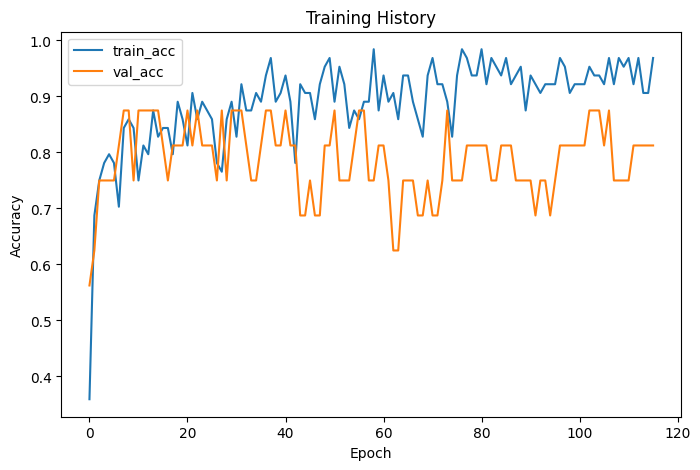

In [ ]:
# -----------------------------
# 1️⃣ Imports
# -----------------------------
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 2️⃣ Load Data
# -----------------------------
train_data = pd.read_csv("/content/drive/MyDrive/SegmentationResults/train_patient_features_from_predicted_masks.csv")
test_data  = pd.read_csv("/content/drive/MyDrive/SegmentationResults/test_patient_features_from_predicted_masks.csv")

feature_cols = ["LV_ESV_mL","RV_EDV_mL","RV_ESV_mL","LV_EDV_mL",
                "LVEF_percent","RVEF_percent","Wall_Thickness_mm","Septal_Thickness_mm"]

X_train = train_data[feature_cols].values
y_train = train_data["target"].values

X_test = test_data[feature_cols].values
y_test = test_data["target"].values

# -----------------------------
# 3️⃣ Encode Labels & Scale
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_classes = len(np.unique(y_train_enc))
input_dim = X_train_scaled.shape[1]

# -----------------------------
# 4️⃣ Define Hybrid TabNet+Transformer Model
# -----------------------------
def build_tabnet_transformer(input_dim, num_classes, embed_dim=32, nhead=4, num_layers=2):
    # Input
    inputs = layers.Input(shape=(input_dim,), dtype=tf.float32)

    # TabNet-like Dense Blocks (simulating tabular attention)
    x = layers.Dense(embed_dim, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(embed_dim, activation='relu')(x)

    # Transformer Encoder
    x_trans = layers.Reshape((1, embed_dim))(x)  # seq_len=1
    for _ in range(num_layers):
        # Multi-head self attention
        attn = layers.MultiHeadAttention(num_heads=nhead, key_dim=embed_dim)(x_trans, x_trans)
        x_trans = layers.Add()([x_trans, attn])
        x_trans = layers.LayerNormalization()(x_trans)
        # Feed-forward
        ff = layers.Dense(embed_dim*2, activation='relu')(x_trans)
        ff = layers.Dense(embed_dim)(ff)
        x_trans = layers.Add()([x_trans, ff])
        x_trans = layers.LayerNormalization()(x_trans)

    x_flat = layers.Flatten()(x_trans)

    # Classification Head
    x_out = layers.Dense(64, activation='relu')(x_flat)
    x_out = layers.Dropout(0.4)(x_out)
    x_out = layers.Dense(32, activation='relu')(x_flat)
    outputs = layers.Dense(num_classes, activation='softmax')(x_out)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# -----------------------------
# 5️⃣ Build & Compile
# -----------------------------
model = build_tabnet_transformer(input_dim, num_classes)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# -----------------------------
# 6️⃣ Train-Validation Split
# -----------------------------
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train_enc, test_size=0.2, random_state=42, stratify=y_train_enc
)

# Callbacks
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/SegmentationResults/tabnet_transformer_best(1).h5",
                                             monitor='val_accuracy', save_best_only=True)

# -----------------------------
# 7️⃣ Train Model
# -----------------------------
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# -----------------------------
# 8️⃣ Evaluate on Test Set
# -----------------------------


# -----------------------------
# 9️⃣ Plot Training History
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()
plt.show()
